# Head pose by projection

Prepared for Shivam Singh · MathTech

## Theory
Pose estimation aligns a generic 3D face model to six observed dense landmarks using solvePnP. This notebook uses explicitly synthetic projected points to check the geometry, not claimed detector results.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.analysis.head_pose import MODEL, INDICES, estimate_pose
k = np.array([[800, 0, 400], [0, 800, 240], [0, 0, 1]], dtype=float)
rotation = np.array([0.08, 0.18, -0.04])
translation = np.array([0., 0., 1500.])
points, _ = cv2.projectPoints(MODEL, rotation, translation, k, np.zeros(5))
synthetic = np.zeros((478, 3)); synthetic[INDICES, :2] = points.reshape(-1, 2)
calibration = {"camera_matrix": k.tolist(), "distortion_coefficients": [0]*5, "resolution": [800,480]}
pose = estimate_pose(Landmarks(synthetic, "dense"), (480,800,3), calibration)
print({key: value for key, value in pose.items() if key != "axes"})


{'pitch': 4.424187120896673, 'yaw': 10.392189634928782, 'roll': -1.8967428037001577, 'calibrated': True}


## Visualization

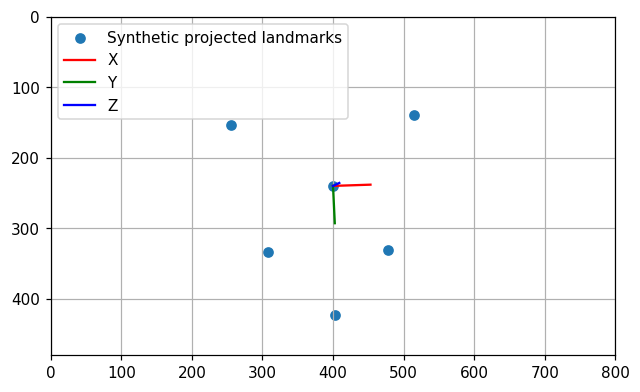

In [3]:
xy = points.reshape(-1,2); axis = np.array(pose["axes"])
plt.scatter(xy[:,0], xy[:,1], label="Synthetic projected landmarks")
for endpoint, color, name in zip(axis[1:], ["r", "g", "b"], ["X", "Y", "Z"]):
    plt.plot([axis[0,0], endpoint[0]], [axis[0,1], endpoint[1]], color=color, label=name)
plt.xlim(0,800); plt.ylim(480,0); plt.gca().set_aspect("equal"); plt.legend(); plt.show()


## Experiment

In [4]:
reference = cv2.RQDecomp3x3(cv2.Rodrigues(rotation)[0])[0]
assert np.allclose([pose["pitch"], pose["yaw"], pose["roll"]], reference, atol=.1)
print("Projected-reference pose test passed")


Projected-reference pose test passed


## Observations
Perturb point coordinates, change intrinsics, and compare recovered angles. A real camera requires calibration, actual dense landmarks and validation of axis conventions.

## Conclusion
Projection consistency is testable; generic face dimensions still limit physical interpretation.